In [6]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
print(train.shape, test.shape)
train.head()

(440679, 3) (48965, 3)


,text,label,dataset
0,ürünü hepsiburadadan alalı 3 hafta oldu. orjin...,Positive,urun_yorumlari
1,"ürünlerden çok memnunum, kesinlikle herkese ta...",Positive,urun_yorumlari
2,"hızlı kargo, temiz alışveriş.teşekkür ederim.",Positive,urun_yorumlari
3,Çünkü aranan tapınak bu bölgededir .,Notr,wiki
4,bu telefonu başlıca alma nedenlerim ise elimde...,Positive,urun_yorumlari


In [7]:
for label in ["Positive", "Negative", "Notr"]:
    print(f"\n===== {label} =====")
    for t in train[train.label == label].text.sample(8, random_state=1):
        print("-", t[:150])


===== Positive =====
- ürün güzel fiyatı da uygun tavsiye ederim
- hangisini alsam diye çok düşünmüştüm ama iyiki bu markayı almışım çok memnunum çekim gücü çok yüksek. tavsiye ederim. çok fazla yer kaplamıyor kolay t
- sipariş edip elime gelene kadar acaba tek hatmı cift hatmı diye endişem vardı. günlerce yorumlardan anlamaya çalıştım. telefon dün elime ulaştı ve cif
- herkeze tavsiyye ederim....  world kart kampanyalarida cabasi
- gayet iyi.ekran parlaklığı,görüntüsü ve hızı çok iyi.şarzı 1 günü çıkarıyor.parasına göre harika
- gerek yumoş kalitesi gerekse hb kargo avantajı ile kaçırılmaması gerek.
- bu kadar çabuk geleceğini beklemiyordum. ürünün kokusu çok güzel ama daha kullanmadım. teşekkürler hb
- Olumsuz yönleri: mor renk sipariş verdik mavi gelmiş neyse artik geri gönderip tekrar ugraşamazdik.

===== Negative =====
- ürünün fiyatı düşük ve buna uygun olarak kaliteli bir ürün değil. üzerindeki plastikler çok rahat kopuyor ve müzik kısmı da çalışmadı. daha farklı seç
-  ya böyl

label
Positive    235949
Notr        153825
Negative     50905
Name: count, dtype: int64

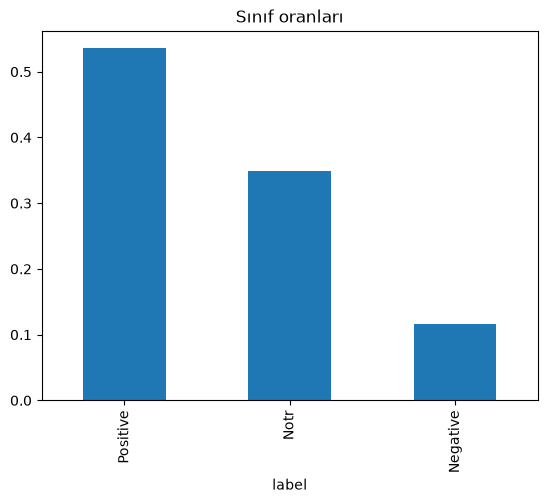

In [8]:
train.label.value_counts(normalize=True).plot.bar(title="Sınıf oranları")
train.label.value_counts()

In [9]:
pd.crosstab(train.dataset, train.label)

label,Negative,Notr,Positive
dataset,,,
HUMIR,29265,0,29310
magaza_yorumlari,3810,0,3817
random,0,461,0
tweet-pn,4456,0,5503
urun_yorumlari,13374,0,197319
wiki,0,153364,0


In [10]:
train["kelime_sayisi"] = train.text.str.split().str.len()
train.groupby("label").kelime_sayisi.describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Negative,50905.0,37.064414,54.409366,1.0,11.0,22.0,41.0,2329.0
Notr,153825.0,8.655901,3.020132,1.0,6.0,8.0,11.0,92.0
Positive,235949.0,23.207371,24.905373,1.0,9.0,19.0,29.0,2724.0


In [11]:
ozellik = train.text.str.endswith(" .")
ozellik.groupby(train.label).mean()

label
Negative    0.002573
Notr        0.988064
Positive    0.005819
Name: text, dtype: float64

In [12]:
print("Train içinde tekrar eden metin:", train.text.duplicated().sum())
print("Hem train hem test'te olan metin:", len(set(train.text) & set(test.text)))
celiski = train.groupby("text").label.nunique()
print("Aynı metin, farklı etiket:", (celiski > 1).sum())

Train içinde tekrar eden metin: 621
Hem train hem test'te olan metin: 127
Aynı metin, farklı etiket: 65
